<a href="https://colab.research.google.com/github/MridulSharma02/Deep-Learning-2025-26-Mridul-Sharma/blob/main/DL_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
# One-hot encoding
y = to_categorical(y)
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential()
model.add(Dense(10, activation='relu', input_shape=(4,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=8,
                    validation_split=0.1,
                    verbose=1)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4222 - loss: 1.0529 - val_accuracy: 0.5833 - val_loss: 1.0141
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3915 - loss: 1.0055 - val_accuracy: 0.5833 - val_loss: 0.9838
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6637 - loss: 0.9268 - val_accuracy: 0.6667 - val_loss: 0.9489
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7912 - loss: 0.8738 - val_accuracy: 0.6667 - val_loss: 0.9127
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7912 - loss: 0.8075 - val_accuracy: 0.7500 - val_loss: 0.8753
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7781 - loss: 0.7784 - val_accuracy: 0.7500 - val_loss: 0.8401
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7976 - loss: 0.7197 - val_accuracy: 0.8333 - val_loss: 0.8043
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8139 - loss: 0.6617 - val_accuracy: 0.8333 - 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0500
Test Accuracy: 1.0


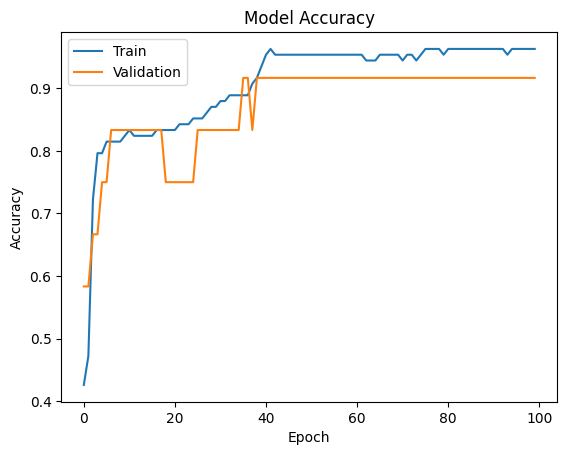

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

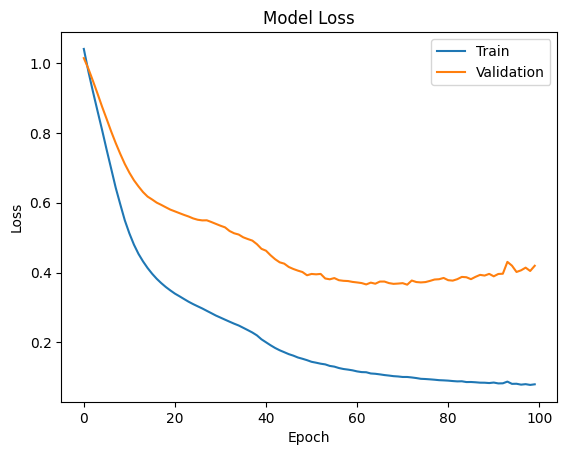

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

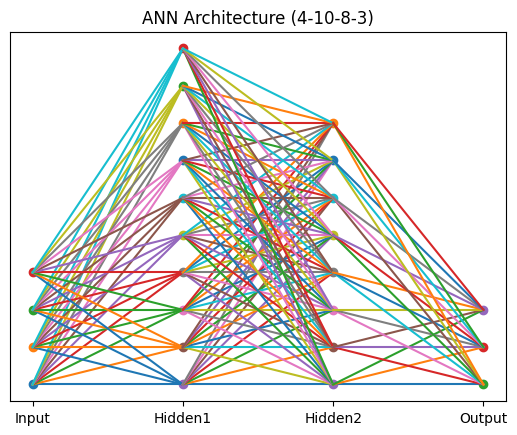

In [ ]:
plt.figure()
input_layer = [(0, i) for i in range(4)]
hidden1 = [(1, i) for i in range(10)]
hidden2 = [(2, i) for i in range(8)]
output_layer = [(3, i) for i in range(3)]
# Plot neurons
for layer in [input_layer, hidden1, hidden2, output_layer]:
    for (x, y) in layer:
        plt.scatter(x, y)
# Draw connections
for (x1, y1) in input_layer:
    for (x2, y2) in hidden1:
        plt.plot([x1, x2], [y1, y2])
for (x1, y1) in hidden1:
    for (x2, y2) in hidden2:
        plt.plot([x1, x2], [y1, y2])
for (x1, y1) in hidden2:
    for (x2, y2) in output_layer:
        plt.plot([x1, x2], [y1, y2])
plt.title("ANN Architecture (4-10-8-3)")
plt.xticks([0,1,2,3], ["Input", "Hidden1", "Hidden2", "Output"])
plt.yticks([])
plt.show()